To define the chemical space of the MetAP project, I will do two plots being (1) BublePlot of the metals used, showing how many of them we have, and (2) a bar plot showing the reported vs ours against the medical indication

In [14]:
import pandas as pd

df = pd.read_csv("OUR-database.csv")
display(df)

,Name,Indication,Metal,PubChem_ID,CCDC,ATC
0,cisplatin,metallodrug,Pt,5460033,CUKRAB,A01X
1,picoplatin,metallodrug,Pt,177358,NaN,A01X
2,oxaliplatin,metallodrug,Pt,9887053,CUKRAB,A01X
3,satraplatin,metallodrug,Pt,123974,NaN,A01X
4,iproplatin,metallodrug,Pt,155491322,NaN,A01X
5,imifoplatin,metallodrug,Pt,25241709,NaN,A01X
6,nedaplatin,metallodrug,Pt,9796440,NaN,A01X
7,lobaplatin,metallodrug,Pt,10000860,NaN,A01X
8,carboplatin,metallodrug,Pt,10339178,NaN,A01X
9,aurothiomalate,metallodrug,Au,422786,NaN,M01C


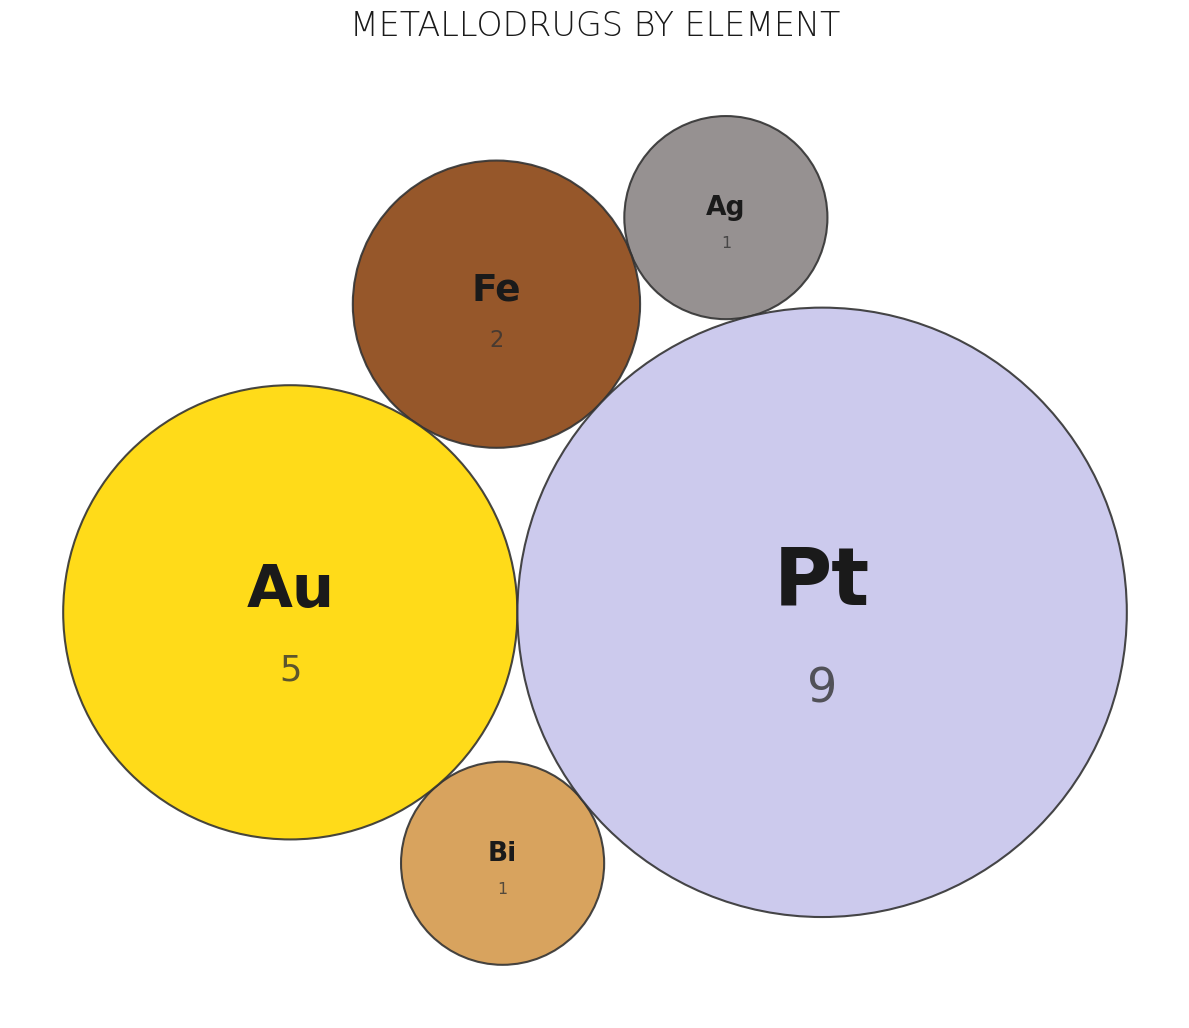

In [15]:
import matplotlib.pyplot as plt
import circlify
import pandas as pd
import matplotlib as mpl

counts = df['Metal'].value_counts().reset_index()
counts.columns = ['metal', 'metallodrugs']

# Sort for better visual packing
df = counts.sort_values('metallodrugs', ascending=False).reset_index(drop=True)

# Convert to dictionary for circlify
data_dict = [{"id": row['metal'], "datum": row['metallodrugs']} for _, row in df.iterrows()]
circles = circlify.circlify(data_dict, show_enclosure=False, target_enclosure=circlify.Circle(x=0, y=0, r=1))

# --- Setup Plot ---
fig, ax = plt.subplots(figsize=(12, 12), facecolor='#FFFFFF')
ax.set_aspect('equal')

# Calculate boundaries
all_x = [c.x + c.r for c in circles] + [c.x - c.r for c in circles]
all_y = [c.y + c.r for c in circles] + [c.y - c.r for c in circles]
padding = 0.1 
ax.set_xlim(min(all_x) - padding, max(all_x) + padding)
ax.set_ylim(min(all_y) - padding, max(all_y) + padding)
ax.axis('off')

# --- Custom Color Mapping ---
element_colors = {
    'Pt': "#c7c5eb",
    'Au': '#FFD700',
    'Fe': '#8B4513',
    'Bi': "#D4994C",
    'Ag': "#8B8585",
    'default': '#E2E2E2' 
}

# --- Plotting Loop ---
for circle in circles:
    x, y, r = circle.x, circle.y, circle.r
    label = circle.ex['id']
    value = circle.ex['datum']
    
    fill_color = element_colors.get(label, element_colors['default'])
    
    ax.add_patch(plt.Circle((x, y), r, alpha=0.9, linewidth=1.5, 
                            facecolor=fill_color, edgecolor="#333333"))
    
    # Text sizing based on circle radius
    if r > 0.03:
        ax.text(x, y + (r*0.1), str(label), 
                va='center', ha='center', 
                fontsize=r*100, 
                fontweight='bold',
                color='#1A1A1A')
        
        ax.text(x, y - (r*0.25), f"{int(value)}", 
                va='center', ha='center', 
                fontsize=r*60, 
                color='#333333',
                alpha=0.8)

# --- Title ---
ax.set_title("METALLODRUGS BY ELEMENT", 
             fontsize=24, 
             fontweight='light', 
             color='#1A1A1A', 
             pad=20)

plt.tight_layout()
plt.show()

In [16]:
display(df)

,metal,metallodrugs
0,Pt,9
1,Au,5
2,Fe,2
3,Bi,1
4,Ag,1
